BƯỚC 1: ĐỌC DỮ LIỆU - PIMA INDIANS DIABETES DATABASE

Xem 5 dòng đầu tiên:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  

Kích thước dữ liệu: 768 dòng, 9 cột

MÔ TẢ CÁC THUỘC TÍNH:
--------------------------------------------------------------------------------
  • Pregnancies              : Số lần mang thai
  • Glucose                  : Nồng độ 

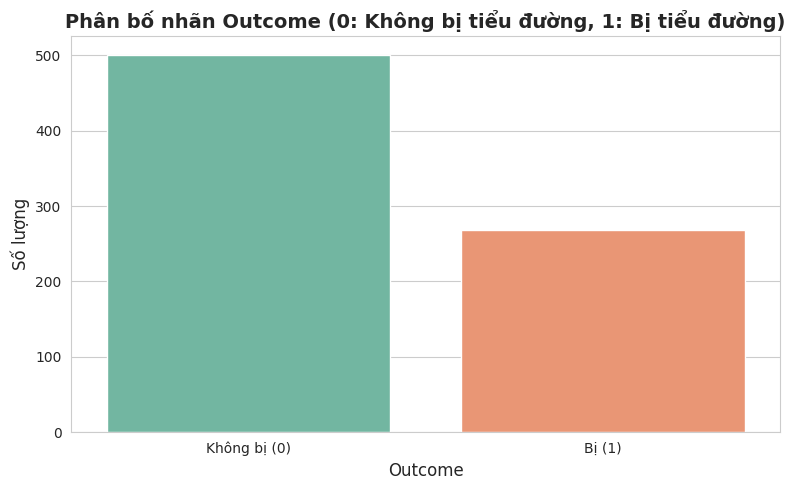

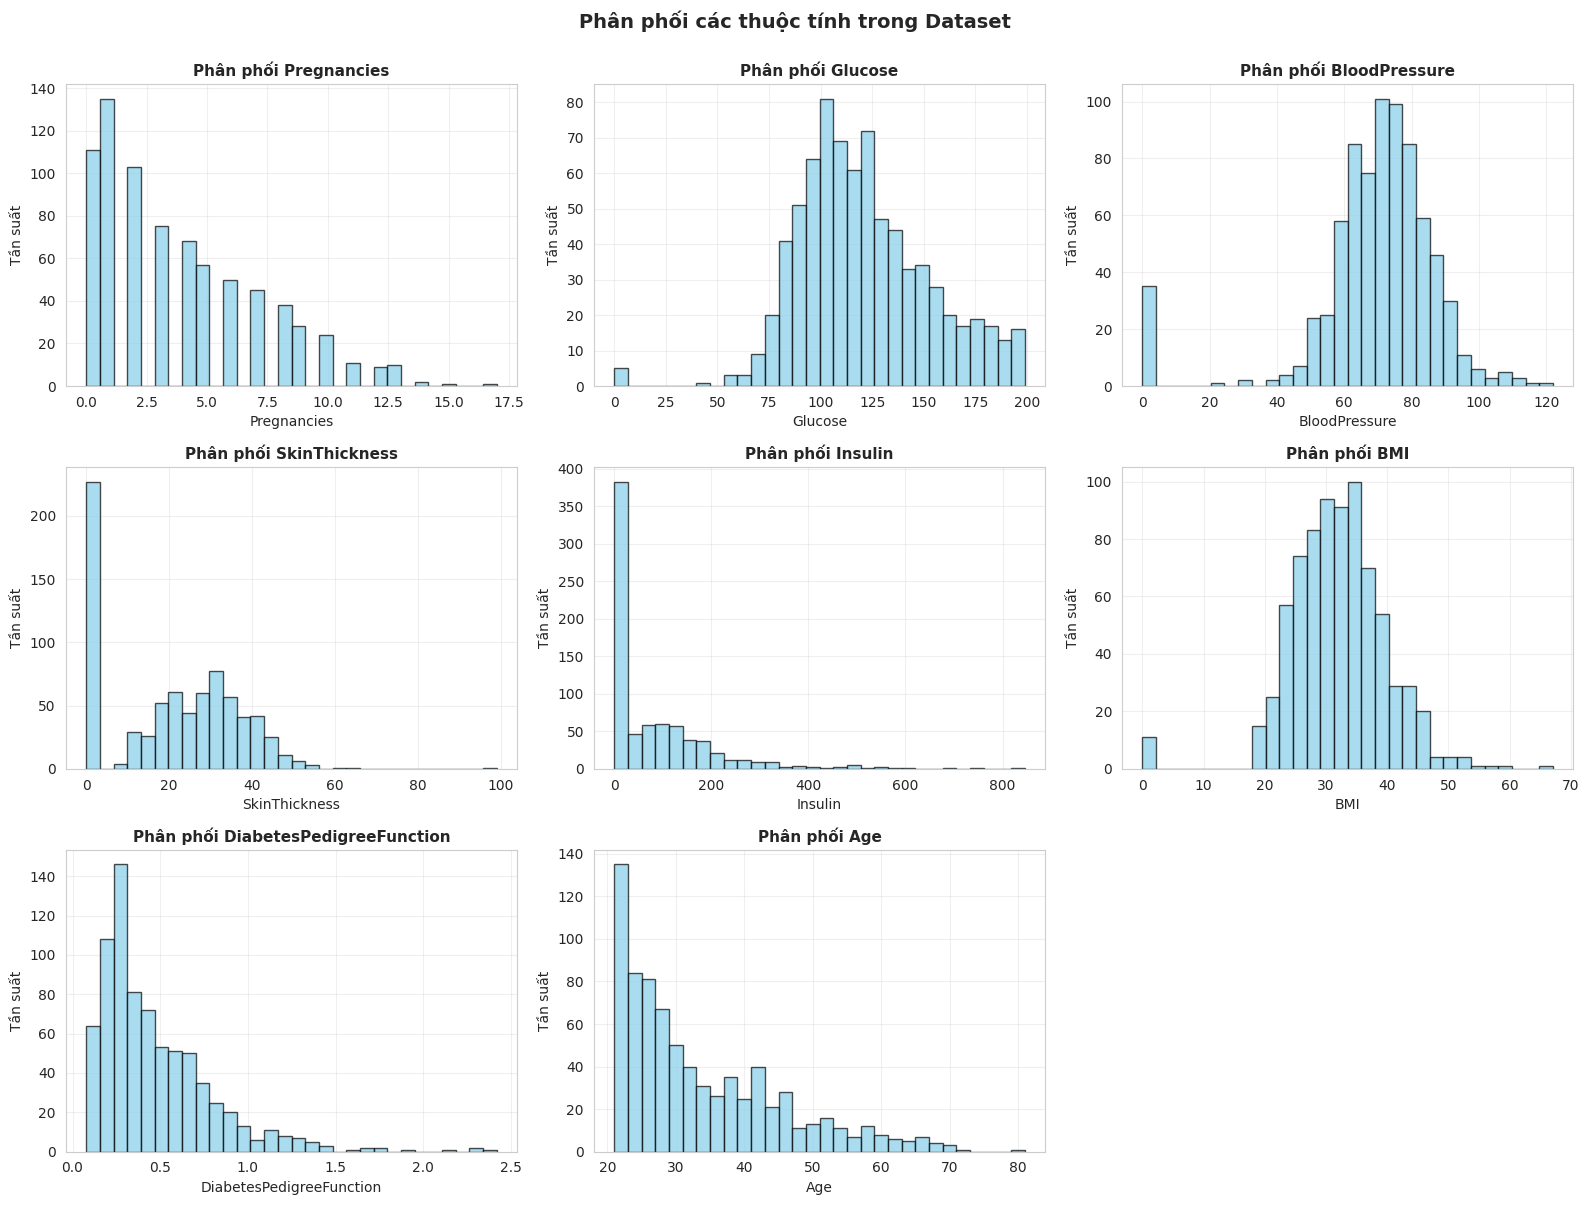

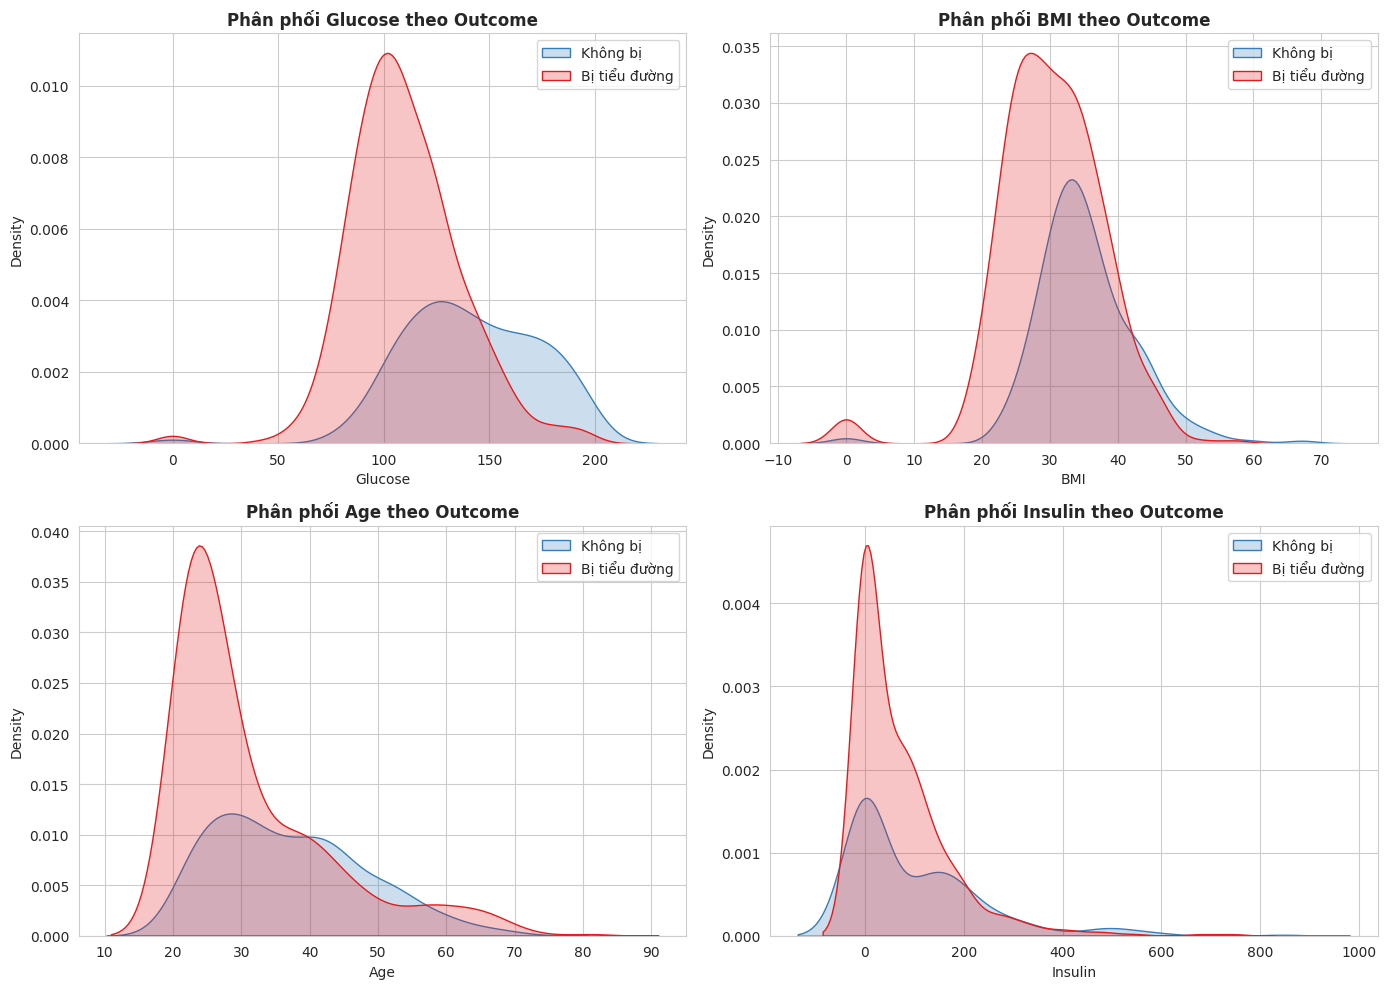

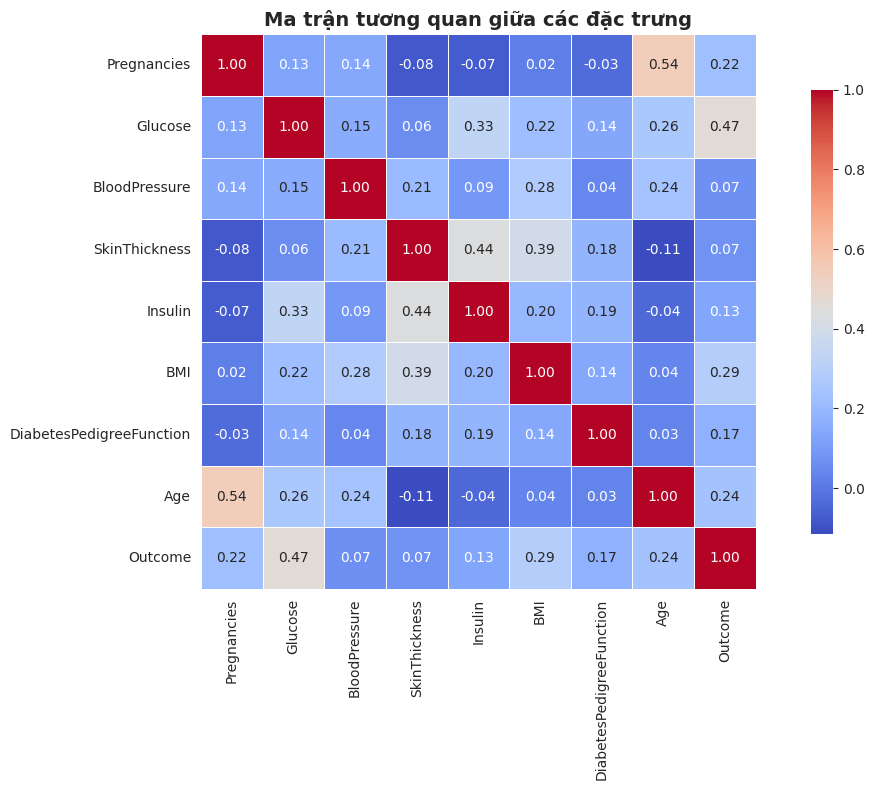

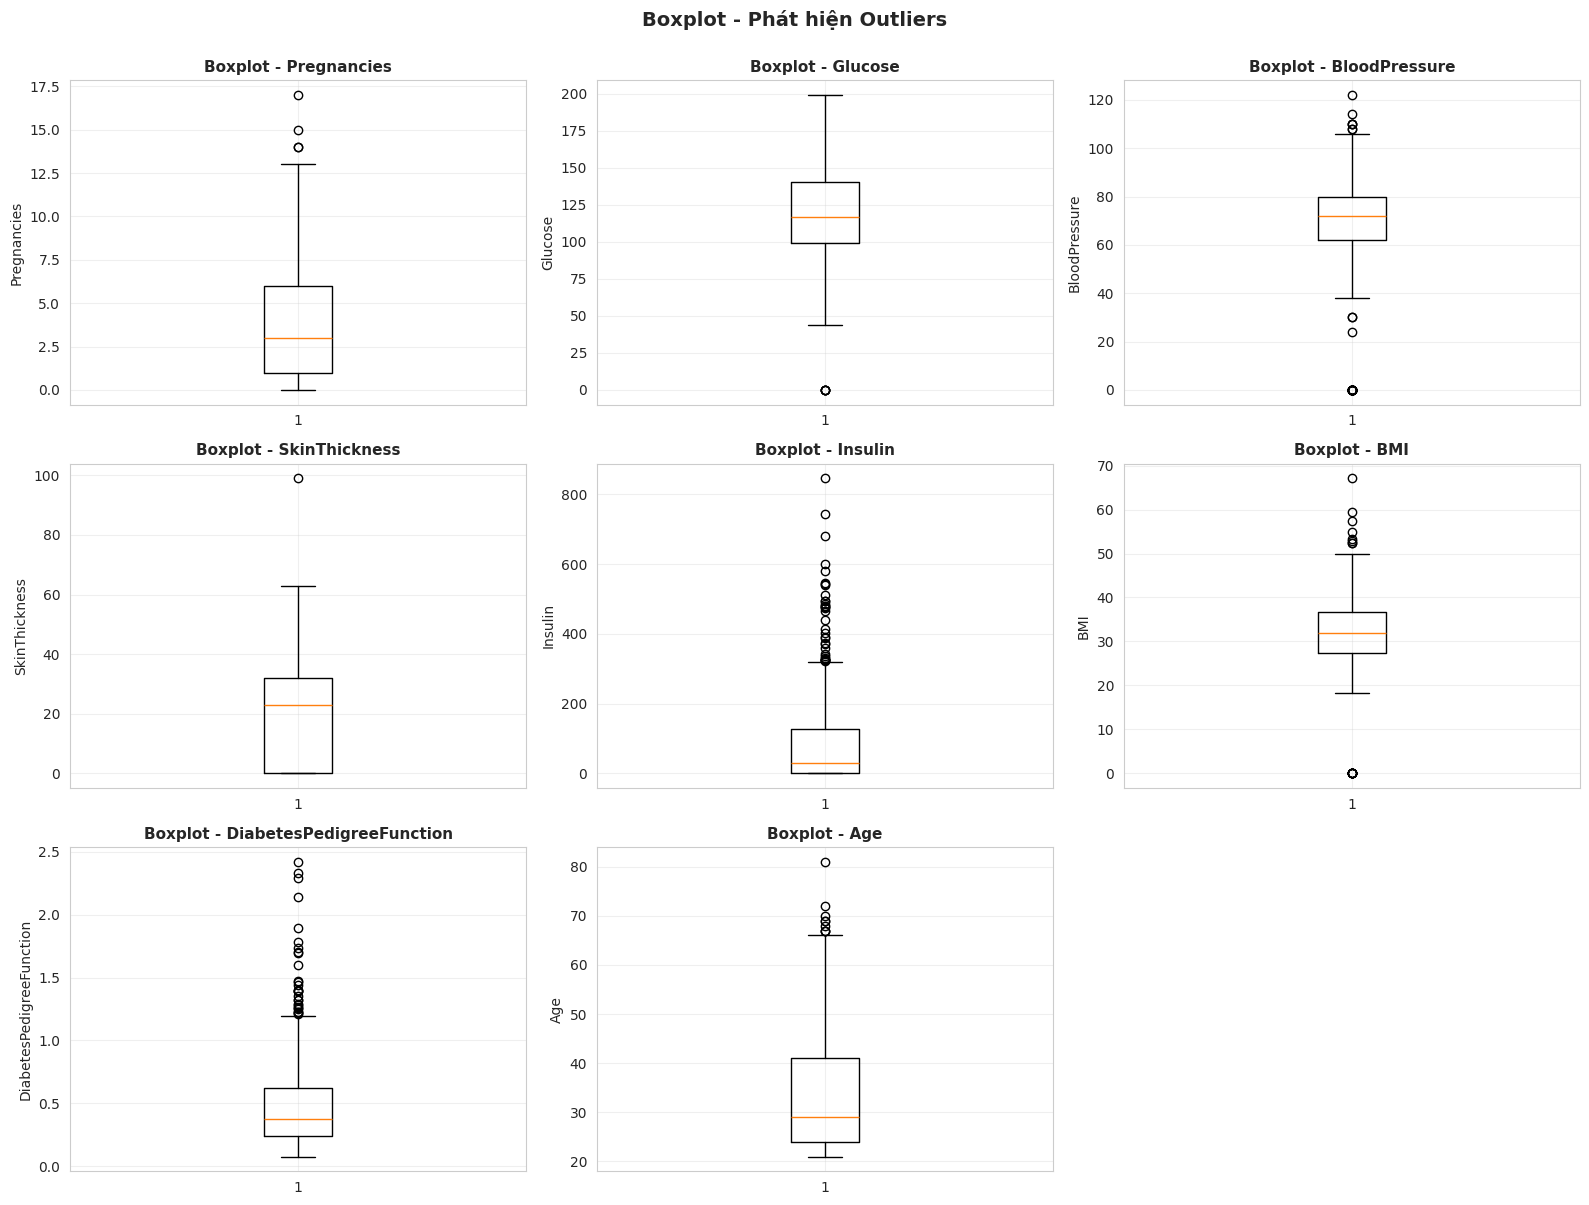


BƯỚC 4: LÀM SẠCH DỮ LIỆU

Đã thay thế giá trị 0 bằng NaN trong các cột: ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

Số lượng giá trị thiếu sau khi xử lý:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

------------------------------------------------------------
DATASET 1: Thay giá trị thiếu bằng MEAN
------------------------------------------------------------
  - Glucose: Thay NaN bằng mean = 121.69
  - BloodPressure: Thay NaN bằng mean = 72.41
  - SkinThickness: Thay NaN bằng mean = 29.15
  - Insulin: Thay NaN bằng mean = 155.55
  - BMI: Thay NaN bằng mean = 32.46

Dataset 1 đã hoàn thành!
Số lượng giá trị thiếu còn lại: 0

------------------------------------------------------------
DATASET 2: Thay giá trị thiế

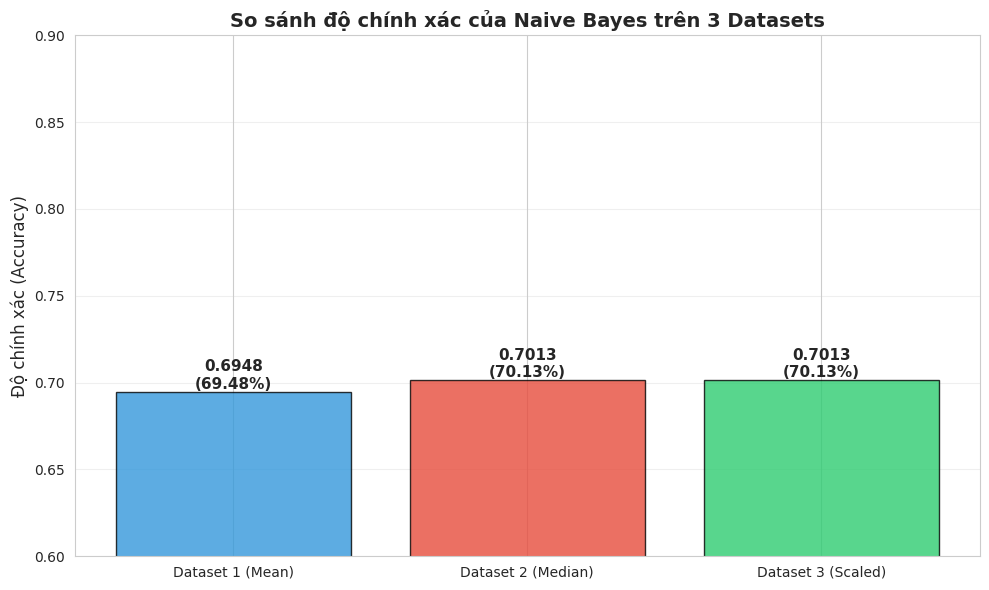

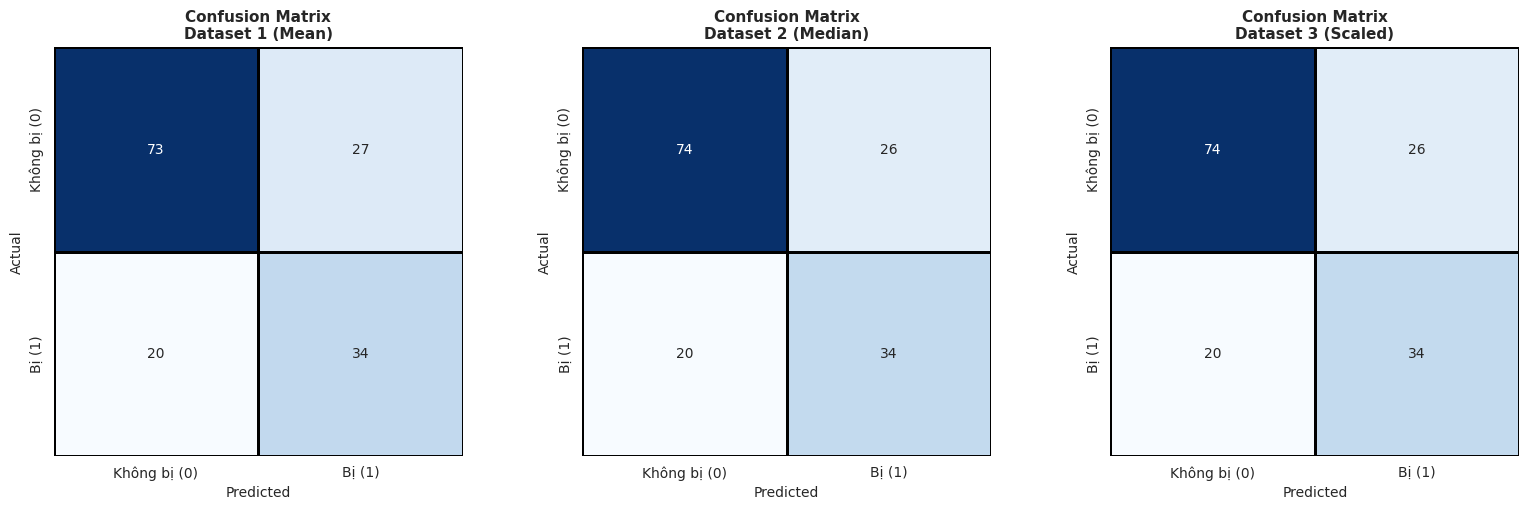


BƯỚC 8: LƯU DỮ LIỆU ĐÃ XỬ LÝ
Đã lưu: diabetes_dataset1_mean.csv
Đã lưu: diabetes_dataset2_median.csv
Đã lưu: diabetes_dataset3_scaled.csv

HOÀN THÀNH TẤT CẢ CÁC BƯỚC!


In [3]:
# ===========================
# PHÂN TÍCH VÀ TIỀN XỬ LÝ DỮ LIỆU - PIMA INDIANS DIABETES DATABASE
# ===========================

# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# ===========================
# 1. ĐỌC DỮ LIỆU
# ===========================
print("="*60)
print("BƯỚC 1: ĐỌC DỮ LIỆU - PIMA INDIANS DIABETES DATABASE")
print("="*60)

df = pd.read_csv('diabetes_structured.csv')

print("\nXem 5 dòng đầu tiên:")
print(df.head())

print(f"\nKích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột")

print("\nMÔ TẢ CÁC THUỘC TÍNH:")
print("-" * 80)
attributes_info = {
    'Pregnancies': 'Số lần mang thai',
    'Glucose': 'Nồng độ glucose trong máu sau 2 giờ test dung nạp glucose (mg/dL)',
    'BloodPressure': 'Huyết áp tâm trương (mm Hg)',
    'SkinThickness': 'Độ dày nếp gấp da cơ tam đầu (mm)',
    'Insulin': 'Insulin huyết thanh sau 2 giờ (mu U/ml)',
    'BMI': 'Chỉ số khối cơ thể (weight in kg/(height in m)^2)',
    'DiabetesPedigreeFunction': 'Hàm phả hệ tiểu đường (chỉ số di truyền)',
    'Age': 'Tuổi (năm)',
    'Outcome': 'Kết quả (0: Không bị tiểu đường, 1: Bị tiểu đường)'
}

for col, desc in attributes_info.items():
    if col in df.columns:
        print(f"  • {col:<25}: {desc}")

print("-" * 80)
print(f"Dataset gồm: 768 bệnh nhân, trong đó 268 người bị tiểu đường (34.9%)")
print("="*80)

# ===========================
# 2. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
# ===========================
print("\n" + "="*60)
print("BƯỚC 2: PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)")
print("="*60)

print("\nThông tin tổng quan về dataset:")
print(df.info())

print("\nThống kê mô tả:")
print(df.describe())

print("\nKiểm tra giá trị thiếu:")
print(df.isnull().sum())

print("\nKiểm tra số lượng giá trị 0 trong các cột (có thể là giá trị thiếu):")
print("   (Giá trị 0 ở các cột này là bất thường vì không thể có glucose, huyết áp, BMI = 0)")
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in zero_cols:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        print(f"  • {col:<20}: {zero_count:>3} giá trị 0 ({zero_count/len(df)*100:>5.2f}%)")

print("\nPhân bố nhãn Outcome (Kết quả chẩn đoán tiểu đường):")
if 'Outcome' in df.columns:
    outcome_counts = df['Outcome'].value_counts()
    print(outcome_counts)
    print(f"\n  • Không bị tiểu đường (0): {outcome_counts[0]} người ({outcome_counts[0]/len(df)*100:.2f}%)")
    print(f"  • Bị tiểu đường (1)      : {outcome_counts[1]} người ({outcome_counts[1]/len(df)*100:.2f}%)")
    print(f"\n  Tỷ lệ: {outcome_counts[0]/outcome_counts[1]:.2f}:1 (Không cân bằng - Imbalanced)")

# ===========================
# 3. TRỰC QUAN HÓA DỮ LIỆU
# ===========================
print("\n" + "="*60)
print("BƯỚC 3: TRỰC QUAN HÓA DỮ LIỆU")
print("="*60)

if 'Outcome' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Outcome', palette='Set2')
    plt.title('Phân bố nhãn Outcome (0: Không bị tiểu đường, 1: Bị tiểu đường)', fontsize=14, fontweight='bold')
    plt.xlabel('Outcome', fontsize=12)
    plt.ylabel('Số lượng', fontsize=12)
    plt.xticks([0, 1], ['Không bị (0)', 'Bị (1)'])
    plt.tight_layout()
    plt.show()

numeric_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    if col in df.columns and idx < len(axes):
        axes[idx].hist(df[col], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
        axes[idx].set_title(f'Phân phối {col}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel(col, fontsize=10)
        axes[idx].set_ylabel('Tần suất', fontsize=10)
        axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Phân phối các thuộc tính trong Dataset', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

important_features = ['Glucose', 'BMI', 'Age', 'Insulin']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for idx, col in enumerate(important_features):
    if col in df.columns:
        sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, ax=axes[idx], palette='Set1')
        axes[idx].set_title(f'Phân phối {col} theo Outcome', fontsize=12, fontweight='bold')
        axes[idx].legend(labels=['Không bị', 'Bị tiểu đường'])

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Ma trận tương quan giữa các đặc trưng', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

numeric_cols_plot = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                     'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols_plot):
    if col in df.columns and idx < len(axes):
        axes[idx].boxplot(df[col].dropna())
        axes[idx].set_title(f'Boxplot - {col}', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel(col, fontsize=10)
        axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols_plot), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# ===========================
# 4. LÀM SẠCH DỮ LIỆU
# ===========================
print("\n" + "="*60)
print("BƯỚC 4: LÀM SẠCH DỮ LIỆU")
print("="*60)

df_clean = df.copy()
for col in zero_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].replace(0, np.nan)

print("\nĐã thay thế giá trị 0 bằng NaN trong các cột:", zero_cols)

print("\nSố lượng giá trị thiếu sau khi xử lý:")
print(df_clean.isnull().sum())

# Dataset 1 - Mean
print("\n" + "-"*60)
print("DATASET 1: Thay giá trị thiếu bằng MEAN")
print("-"*60)

df_mean = df_clean.copy()
for col in zero_cols:
    if col in df_mean.columns:
        mean_value = df_mean[col].mean()
        df_mean[col].fillna(mean_value, inplace=True)
        print(f"  - {col}: Thay NaN bằng mean = {mean_value:.2f}")

print("\nDataset 1 đã hoàn thành!")
print(f"Số lượng giá trị thiếu còn lại: {df_mean.isnull().sum().sum()}")

# Dataset 2 - Median
print("\n" + "-"*60)
print("DATASET 2: Thay giá trị thiếu bằng MEDIAN")
print("-"*60)

df_median = df_clean.copy()
for col in zero_cols:
    if col in df_median.columns:
        median_value = df_median[col].median()
        df_median[col].fillna(median_value, inplace=True)
        print(f"  - {col}: Thay NaN bằng median = {median_value:.2f}")

print("\nDataset 2 đã hoàn thành!")
print(f"Số lượng giá trị thiếu còn lại: {df_median.isnull().sum().sum()}")

# Dataset 3 - Scaled
print("\n" + "-"*60)
print("DATASET 3: Chuẩn hóa dữ liệu (từ Dataset 2)")
print("-"*60)

df_scaled = df_median.copy()

if 'Outcome' in df_scaled.columns:
    X_to_scale = df_scaled.drop('Outcome', axis=1)
    y = df_scaled['Outcome']
else:
    X_to_scale = df_scaled

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_to_scale)
X_scaled_df = pd.DataFrame(X_scaled, columns=X_to_scale.columns)

if 'Outcome' in df_scaled.columns:
    df_scaled_final = pd.concat([X_scaled_df, y.reset_index(drop=True)], axis=1)
else:
    df_scaled_final = X_scaled_df

print("Đã chuẩn hóa dữ liệu bằng StandardScaler!")
print("\nThống kê sau khi chuẩn hóa:")
print(df_scaled_final.describe())

# ===========================
# 5. PHÂN CHIA DỮ LIỆU
# ===========================
print("\n" + "="*60)
print("BƯỚC 5: PHÂN CHIA DỮ LIỆU (80% Train - 20% Test)")
print("="*60)

if 'Outcome' not in df.columns:
    print("Cảnh báo: Không tìm thấy cột 'Outcome'. Vui lòng kiểm tra tên cột!")
else:
    X1 = df_mean.drop('Outcome', axis=1)
    y1 = df_mean['Outcome']
    X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1, test_size=0.2, random_state=42, stratify=y1)

    print("\nDataset 1 (Mean):")
    print(f"  - Train: {X1_train.shape[0]} mẫu")
    print(f"  - Test: {X1_test.shape[0]} mẫu")

    X2 = df_median.drop('Outcome', axis=1)
    y2 = df_median['Outcome']
    X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

    print("\nDataset 2 (Median):")
    print(f"  - Train: {X2_train.shape[0]} mẫu")
    print(f"  - Test: {X2_test.shape[0]} mẫu")

    X3 = df_scaled_final.drop('Outcome', axis=1)
    y3 = df_scaled_final['Outcome']
    X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

    print("\nDataset 3 (Scaled):")
    print(f"  - Train: {X3_train.shape[0]} mẫu")
    print(f"  - Test: {X3_test.shape[0]} mẫu")

# ===========================
# 6. HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES
# ===========================
print("\n" + "="*60)
print("BƯỚC 6: HUẤN LUYỆN VÀ ĐÁNH GIÁ MÔ HÌNH NAIVE BAYES")
print("="*60)

if 'Outcome' in df.columns:
    models = {}
    results = {}

    datasets = {
        'Dataset 1 (Mean)': (X1_train, X1_test, y1_train, y1_test),
        'Dataset 2 (Median)': (X2_train, X2_test, y2_train, y2_test),
        'Dataset 3 (Scaled)': (X3_train, X3_test, y3_train, y3_test)
    }

    for name, (X_tr, X_te, y_tr, y_te) in datasets.items():
        print(f"\n{'='*50}")
        print(f"{name}")
        print('='*50)

        nb_model = GaussianNB()
        nb_model.fit(X_tr, y_tr)

        y_pred = nb_model.predict(X_te)

        accuracy = accuracy_score(y_te, y_pred)

        print(f"\nĐộ chính xác (Accuracy): {accuracy:.4f} ({accuracy*100:.2f}%)")

        print("\nClassification Report:")
        print(classification_report(y_te, y_pred, target_names=['Không bị (0)', 'Bị tiểu đường (1)']))

        cm = confusion_matrix(y_te, y_pred)
        print("Confusion Matrix:")
        print(cm)

        models[name] = nb_model
        results[name] = accuracy

    # ===========================
    # 7. SO SÁNH KẾT QUẢ
    # ===========================
    print("\n" + "="*60)
    print("BƯỚC 7: SO SÁNH KẾT QUẢ CÁC DATASET")
    print("="*60)

    print("\nBảng so sánh độ chính xác:")
    print("-" * 60)
    for name, acc in results.items():
        print(f"{name:<30}: {acc:.4f} ({acc*100:.2f}%)")
    print("-" * 60)

    best_dataset = max(results, key=results.get)
    print(f"\nDataset tốt nhất: {best_dataset} với độ chính xác {results[best_dataset]:.4f}")

    plt.figure(figsize=(10, 6))
    datasets_names = list(results.keys())
    accuracies = list(results.values())

    bars = plt.bar(datasets_names, accuracies, color=['#3498db', '#e74c3c', '#2ecc71'], edgecolor='black', alpha=0.8)
    plt.ylabel('Độ chính xác (Accuracy)', fontsize=12)
    plt.title('So sánh độ chính xác của Naive Bayes trên 3 Datasets', fontsize=14, fontweight='bold')
    plt.ylim(0.6, 0.9)
    plt.grid(axis='y', alpha=0.3)

    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{acc:.4f}\n({acc*100:.2f}%)',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    for idx, (name, (X_tr, X_te, y_tr, y_te)) in enumerate(datasets.items()):
        y_pred = models[name].predict(X_te)
        cm = confusion_matrix(y_te, y_pred)

        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                    cbar=False, square=True, linewidths=1, linecolor='black')
        axes[idx].set_title(f'Confusion Matrix\n{name}', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Predicted', fontsize=10)
        axes[idx].set_ylabel('Actual', fontsize=10)
        axes[idx].set_xticklabels(['Không bị (0)', 'Bị (1)'])
        axes[idx].set_yticklabels(['Không bị (0)', 'Bị (1)'])

    plt.tight_layout()
    plt.show()

# ===========================
# 8. LƯU DỮ LIỆU ĐÃ XỬ LÝ
# ===========================
print("\n" + "="*60)
print("BƯỚC 8: LƯU DỮ LIỆU ĐÃ XỬ LÝ")
print("="*60)

df_mean.to_csv('diabetes_dataset1_mean.csv', index=False)
print("Đã lưu: diabetes_dataset1_mean.csv")

df_median.to_csv('diabetes_dataset2_median.csv', index=False)
print("Đã lưu: diabetes_dataset2_median.csv")

df_scaled_final.to_csv('diabetes_dataset3_scaled.csv', index=False)
print("Đã lưu: diabetes_dataset3_scaled.csv")

print("\n" + "="*60)
print("HOÀN THÀNH TẤT CẢ CÁC BƯỚC!")
print("="*60)
